In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('Salary_Data.csv')
X = df.iloc[:, 0]
y = df.iloc[:, 1]
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train = X_train.values.reshape(-1, 1)

learner = LinearRegression()
learner.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [3]:
y_pred = learner.predict(X_test.values.reshape(-1, 1))
print(y_pred.reshape(-1, 1))

[[ 40748.96184072]
 [122699.62295594]
 [ 64961.65717022]
 [ 63099.14214487]
 [115249.56285456]
 [107799.50275317]]


In [4]:
y_test

2      37731.0
28    122391.0
13     57081.0
10     63218.0
26    116969.0
24    109431.0
Name: Salary, dtype: float64

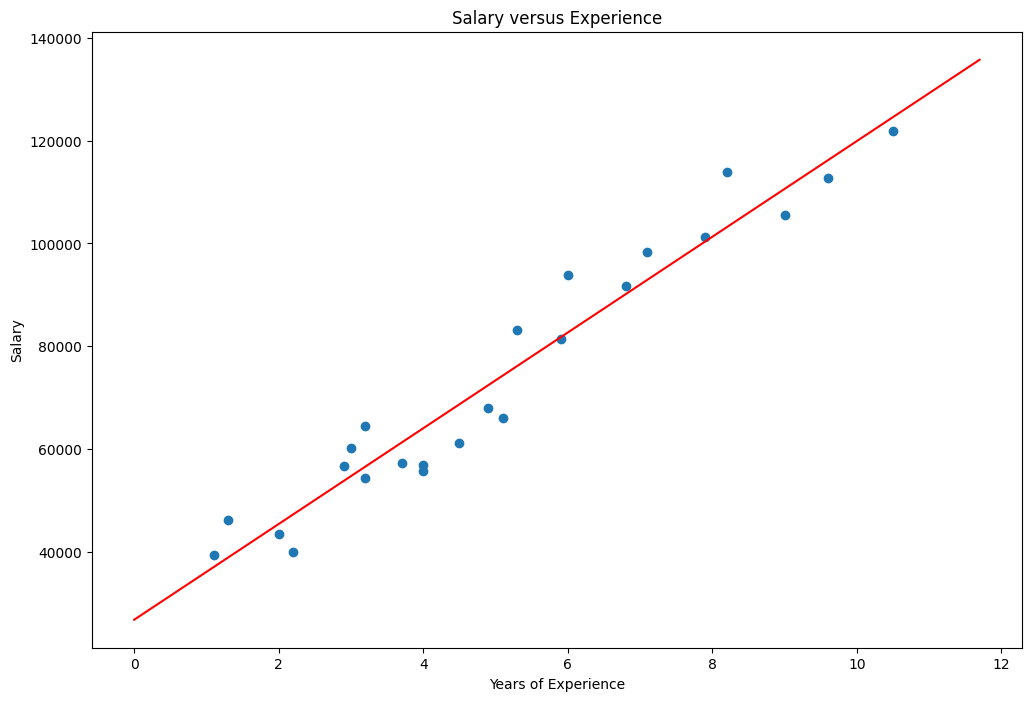

In [5]:
fig = plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train)
plt.plot(np.arange(0, 12, 0.3), learner.predict(np.arange(0, 12, 0.3).reshape(-1, 1)), color='red')
plt.title('Salary versus Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [6]:
# Polynomial linear regression
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


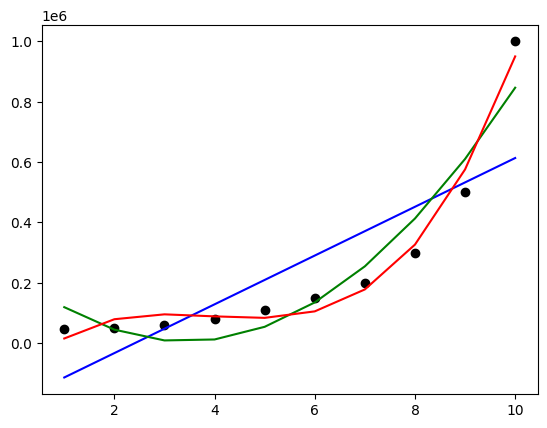

In [7]:
X = df.iloc[:, 1:2]
y = df.iloc[:, 2]

from sklearn.preprocessing import PolynomialFeatures
poly_reg_2 = PolynomialFeatures(degree=2)
poly_reg_3 = PolynomialFeatures(degree=3)
X_poly_2 = poly_reg_2.fit_transform(X)
X_poly_3 = poly_reg_3.fit_transform(X)

lin = LinearRegression().fit(X, y)
lin_poly_2 = LinearRegression().fit(X_poly_2, y)
lin_poly_3 = LinearRegression().fit(X_poly_3, y)

plt.scatter(X, y, color='black')
plt.plot(X, lin.predict(X), color='b')
plt.plot(X,lin_poly_2.predict(poly_reg_2.fit_transform(X)), color='g')
plt.plot(X, lin_poly_3.predict(poly_reg_3.fit_transform(X)), color='red')
plt.show()